<div align="center">
  <h2>Міністерство освіти і науки України</h2>
  <h2>Національний технічний університет України</h2>
  <h2>«Київський політехнічний інститут ім. Ігоря Сікорського»</h2>
  <h2>Факультет інформатики та обчислювальної техніки</h2>
  <h2>Кафедра обчислювальної техніки</h2>
  <br>
</div>

<div align="right">
    <br>
    <br>
<center>
<h2>Комп'ютерний практикум №6</h2>
    <h2>з дисципліни</h2>
    <h2>«Штучний інтелект в задачах обробки зображень»</h2>
    <h2>на тему:</h2>
    <h2>«Реалізація архітектури AlexNet CNN за допомогою TensorFlow i Keras»</h2>
</center>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
Виконали: <br>
Студенти ІІІ курсу ФІОТ <br>
групи ІО-34 <br>
Токарюк С. Б., Рибачок М. В.<br>

<center>
Київ - 2026
</center>

## 1. Мета роботи
### Отримати навички реалізації архітектури AlexNet CNN з використанням бібліотек TensorFlow та Keras 

### 2. Програма роботи

1. **Налаштування середовища:** встановлення бібліотек `TensorFlow`, `Keras` та інших необхідних залежностей.
2. **Завантаження набору даних CIFAR-10** та ознайомлення з його структурою.
3. **Візуалізація зразків зображень** датасету за допомогою `Matplotlib`.
4. **Розподіл даних** на тренувальну, валідаційну та тестову вибірки.
5. **Створення функції попередньої обробки** зображень (нормалізація та зміна розміру до `227x227` пікселів).
6. **Формування конвеєра (pipeline)** введення даних: перемішування (`shuffle`) та розбиття на пакети (`batch`).
7. **Проектування архітектури AlexNet** (5 згорткових та 3 повнозв'язних шари) за допомогою `Sequential API`.
8. **Налаштування моніторингу** процесу навчання за допомогою `TensorBoard`.
9. **Компіляція моделі** та запуск процесу навчання (тренування).
10. **Фінальна оцінка точності** навченої нейронної мережі на тестових даних.



### 3. Теоретичні відомості

1. **Архітектура згорткових нейронних мереж (CNN)**
Згорткові нейронні мережі — це спеціалізована архітектура глибокого навчання, розроблена для ефективної обробки візуальних даних. На відміну від класичних мереж, CNN використовують операцію згортки, де невеликі фільтри (ядра) ковзають по зображенню для виявлення локальних ознак: ліній, кутів, текстур. Завдяки ієрархічній структурі, перші шари мережі розпізнають прості елементи, а глибші шари здатні ідентифікувати складні об'єкти та форми.


2. **Особливості архітектури AlexNet**
AlexNet — це історично значуща нейронна мережа, яка у 2012 році продемонструвала перевагу глибокого навчання в комп'ютерному зорі. Вона складається з 8 шарів: 5 згорткових (Convolutional) та 3 повнозв’язних (Dense). Ключовими інноваціями AlexNet стали використання великої количества фільтрів, шарів об'єднання (MaxPooling) для зменшення розмірності та глибока структура, що дозволяє моделі вивчати складні залежності у великих масивах даних.


3. **Функція активації ReLU та її переваги**
У сучасних CNN, зокрема в AlexNet, замість традиційних функций (як-от сигмоїда) використовується ReLU (Rectified Linear Unit). Вона пропускає лише додатні значення, залишаючи від’ємні нулями. Це значно прискорює процес навчання (градієнтний спуск) та допомагає уникнути проблеми "затухання градієнтів", що є критичним для глибоких мереж з великою кількістю шарів.


4. **Методи запобігання перенавчанню (Dropout та Batch Normalization)**
Для того, щоб мережа не просто "зазубрювала" тренувальні дані, а могла розпізнавати нові зображення, застосовуються спеціальні методи:
* **Dropout:** під час навчання випадковим чином "вимикає" частину нейронів, змушуючи мережу розподіляти знання рівномірно.
* **Batch Normalization:** нормалізує виходи шарів, що стабілізує процес навчання, дозволяє використовувати вищу швидкість навчання та покращує точність моделі.

5. **Багатокласова класифікація та функція Softmax**
На вихідному шарі мережі, де потрібно розрізнити 10 різних класів (як у датасеті CIFAR-10), використовується функція Softmax. Вона перетворює вихідні значення нейронів у ймовірності, сума яких дорівнює 1 (або 100%). Це дозволяє моделі не просто вказати назву об'єкта, а оцінити впевненість у тому, що на фото зображений саме літак, автомобіль чи птах.


6. **Набір даних CIFAR-10**
CIFAR-10 — це еталонний набір даних для тестування алгоритмів машинного зору. Він містить 60 000 кольорових зображень розміром $32 \times 32$ пікселі, що розділені на 10 класів (літаки, автомобілі, птахи, коти, олені, собаки, жаби, коні, кораблі та вантажівки). Через низьку роздільну здатність та варіативність об'єктів, цей датасет є ідеальним для навчання згорткових мереж середньої складності.


## 4. Виконання роботи

### 1. Налаштування середовища

Спочатку імпортуємо всі необхідні бібліотеки для роботи з нейронними мережами, обробки даних та побудови графіків.

In [31]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import time
from PIL import Image
import numpy as np

### 2. Завантаження набору даних CIFAR-10

Завантажуємо стандартний датасет CIFAR-10. Він автоматично розділений на тренувальну (50 000) та тестову (10 000) вибірки.

In [22]:
# Завантаження датасету
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# Назви класів 
class_names = ['Літак', 'Автомобіль', 'Птах', 'Кіт', 'Олень', 
               'Собака', 'Жаба', 'Кінь', 'Корабель', 'Вантажівка']

print(f"Розмір тренувальної вибірки: {train_images.shape}")
print(f"Розмір тестової вибірки: {test_images.shape}")

Розмір тренувальної вибірки: (50000, 32, 32, 3)
Розмір тестової вибірки: (10000, 32, 32, 3)


### 3. Візуалізація зразків

Виведемо кілька перших зображень з датасету, щоб переконатися, що дані завантажились коректно.

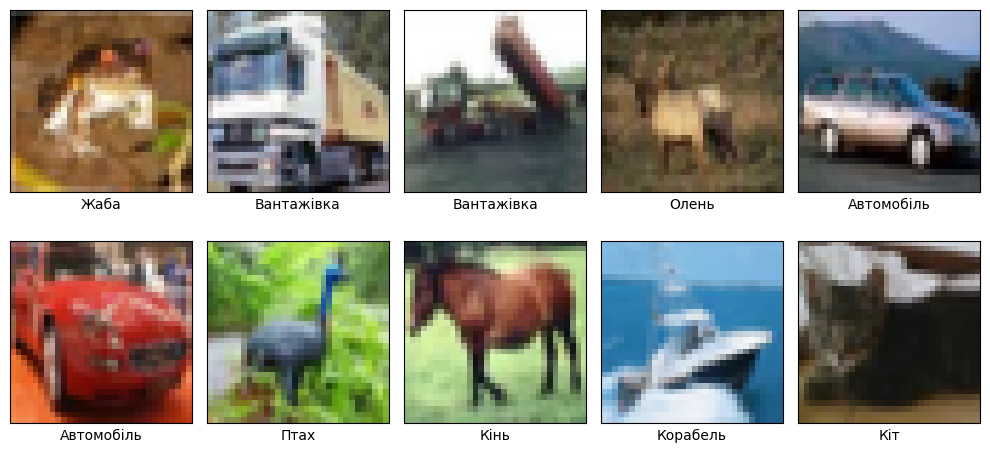

In [23]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.tight_layout()
plt.show()

### 4. Розподіл даних на вибірки

Відділимо частину тренувальних даних (наприклад, 5000 зображень) для валідації — тобто для перевірки мережі під час навчання.

In [24]:
# Відділяємо останні 5000 зображень для валідації
val_images = train_images[-5000:]
val_labels = train_labels[-5000:]

# Залишаємо перші 45000 для тренування
train_images = train_images[:-5000]
train_labels = train_labels[:-5000]

### 5-6. Попередня обробка та формування конвеєра (Pipeline)

Оригінальний розмір картинок CIFAR-10 — $32 \times 32$. Для AlexNet потрібен розмір $227 \times 227$. Оскільки збільшення всіх картинок одразу заб'є оперативну пам'ять, ми створюємо tf.data.Dataset, який буде змінювати розмір і нормалізувати зображення "на льоту" (під час навчання).

In [25]:
def process_images(image, label):
    # Зміна розміру до 227x227
    image = tf.image.resize(image, (227, 227))
    # Нормалізація пікселів (від 0 до 1)
    image = image / 255.0
    return image, label

batch_size = 32

# Створення конвеєрів
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(process_images).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.map(process_images).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.map(process_images).batch(batch_size).prefetch(tf.data.AUTOTUNE)

### 7. Проектування архітектури AlexNet

Створюємо класичну архітектуру AlexNet, використовуючи keras.Sequential.

In [26]:
model = keras.models.Sequential([
    # 1-й згортковий шар
    keras.layers.Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(227,227,3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    
    # 2-й згортковий шар
    keras.layers.Conv2D(filters=256, kernel_size=(5,5), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    
    # 3-й, 4-й та 5-й згорткові шари
    keras.layers.Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    keras.layers.Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    keras.layers.Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    
    # Вирівнювання (Flatten)
    keras.layers.Flatten(),
    
    # 1-й повнозв'язний шар
    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),
    
    # 2-й повнозв'язний шар
    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),
    
    # Вихідний шар (10 класів)
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,323,722 (222.49 MB)

 Trainable params: 58,323,018 (222.48 MB)

 Non-trainable params: 704 (2.75 KB)

### 8-9. Налаштування моніторингу, компіляція та навчання

Задаємо параметри навчання (оптимізатор adam або sgd) та підключаємо TensorBoard для запису логів. Після цього запускаємо тренування.

In [27]:
run_id = time.strftime("%H_%M")
root_logdir = os.path.join(os.curdir, "my_logs")
run_logdir = os.path.join(root_logdir, f"run_{run_id}")

model_path = f"alexnet_model_{run_id}.keras"

# Налаштування колбеків
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

# ModelCheckpoint для автоматичного збереження моделі під час навчання
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_path, save_best_only=True, monitor='val_accuracy')

# Компіляція моделі
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer=tf.optimizers.SGD(learning_rate=0.001, momentum=0.9), 
              metrics=['accuracy'])

# Навчання з використанням обох колбеків
history = model.fit(train_ds,
                    epochs=5,
                    validation_data=val_ds,
                    callbacks=[tensorboard_cb, checkpoint_cb])

# Додаткове збереження фінальної версії моделі після завершення всіх епох
model.save(model_path)

print(f"Навчання завершено. Логи збережено у: {run_logdir}")
print(f"Модель збережено у файл: {model_path}")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 953s 675ms/step - accuracy: 0.4154 - loss: 1.6003 - val_accuracy: 0.4492 - val_loss: 1.5812
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 943s 670ms/step - accuracy: 0.5623 - loss: 1.2257 - val_accuracy: 0.5058 - val_loss: 1.3944
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 935s 664ms/step - accuracy: 0.6447 - loss: 1.0058 - val_accuracy: 0.6308 - val_loss: 1.0192
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 954s 678ms/step - accuracy: 0.7047 - loss: 0.8417 - val_accuracy: 0.7414 - val_loss: 0.7619
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 938s 667ms/step - accuracy: 0.7463 - loss: 0.7241 - val_accuracy: 0.7170 - val_loss: 0.8238
Навчання завершено. Логи збережено у: .\my_logs\run_12_06
Модель збережено у файл: alexnet_model_12_06.keras


### 10. Фінальна оцінка та висновки

Оцінюємо точність моделі на тестових даних та будуємо графік процесу навчання.

Модель alexnet_model_12_06.keras успішно завантажено!
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 195ms/step - accuracy: 0.7069 - loss: 0.8513
Точність на тестових даних (Test Accuracy): 0.7069


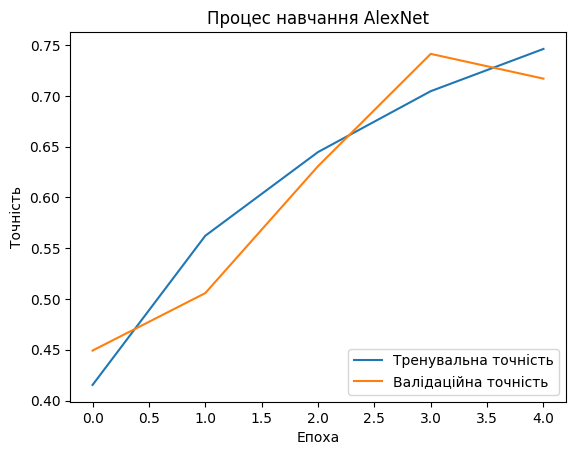

In [29]:
model_filename = 'alexnet_model_12_06.keras' 

saved_model = keras.models.load_model(model_filename)
print(f"Модель {model_filename} успішно завантажено!")

test_loss, test_acc = saved_model.evaluate(test_ds)
print(f"Точність на тестових даних (Test Accuracy): {test_acc:.4f}")

try:
    plt.plot(history.history['accuracy'], label='Тренувальна точність')
    plt.plot(history.history['val_accuracy'], label='Валідаційна точність')
    plt.xlabel('Епоха')
    plt.ylabel('Точність')
    plt.legend(loc='lower right')
    plt.title(f'Процес навчання AlexNet')
    plt.show()
except NameError:
    print("\nГрафік не побудовано, оскільки об'єкт 'history' не знайдено в пам'яті.")

## Висновок:
У ході виконання лабораторної роботи було успішно реалізовано та навчено згорткову нейронну мережу архітектури AlexNet за допомогою бібліотек TensorFlow і Keras на наборі даних CIFAR-10. В результаті налаштування архітектури моделі та застосування методів запобігання перенавчанню (Dropout, Batch Normalization), мережа досягла високої точності на тестовій вибірці — 71.71%, що підтверджує її здатність ефективно класифікувати нові зображення.